# Great Britain 01 — Governance and racing structure

## Research programme

This notebook begins the Inside Rails foundational research programme:

> **How British Horse Racing Actually Works**

The purpose is to understand the institutions, rules, terminology and sporting
structures that give British horse-racing data its meaning.

This is exploratory research rather than a predetermined article. The evidence
will determine both the direction of the study and any eventual reader-facing
story.

The notebook therefore preserves:

- the questions being asked;
- why they matter;
- authoritative definitions and external evidence;
- what Database v3 contains;
- unexpected findings and ambiguities;
- changes of direction;
- what each result does and does not establish;
- why one result leads to the next question.

The working research sequence is:

> **official definition or rule → database representation → observed evidence → interpretation → next question**

Database field names will not be used to define how the sport itself works.

Markdown records the **research reasoning**.

Code comments record the **implementation reasoning**.

---

## Initial bounded question

> **Who governs British horse racing, and how is the sporting activity organised?**

We will begin with the institutions and structural vocabulary of the sport
before attempting to analyse its historical data.

Initial concepts likely to matter include:

- racecourses;
- fixtures;
- meetings;
- races;
- runners and other participation states;
- series and other cross-race programmes.

These concepts will not be forced into a hierarchy before the evidence
establishes their relationships.

---

## Analytical database

The study uses the accepted Inside Rails **Database v3** release read-only:

`data/processed/database/releases/inside_rails_v3.sqlite3`

The normal race-level study interface is:

`view_reconciled_race_occurrences`

Database v3 is the analytical starting point, but it is not the research
ceiling. Authoritative external evidence will be used where the sporting
structure cannot be established from the database alone.

---

## Research status

**Exploratory — opening question in progress.**

# 1. What is the British Horseracing Authority?

## Question

> **What is the BHA, and why should its rules and terminology be treated as
> authoritative evidence about British racing?**

### Why this matters

Much of this study will rely on BHA rules, instructions and administrative
material.

It would be circular simply to accept the BHA's own claim to authority without
first establishing independently what kind of organisation it is and what role
it occupies in British racing.

A sporting governing body, private company, government department and statutory
regulator are not interchangeable concepts.

---

## Evidence / method

The BHA's own material was compared with independent UK government and
Companies House sources.

### Companies House

`BRITISH HORSERACING AUTHORITY LIMITED`

Company number: `02813358`

Companies House records the organisation as an active:

> **private company limited by guarantee without share capital**

The company was previously named `THE BRITISH HORSERACING BOARD LIMITED`.

This establishes that the BHA is a corporate body rather than a government
department.

### UK Government recognition

GOV.UK identifies the British Horseracing Authority as the recognised sports
governing body for horseracing.

Separate government guidance concerning racecourses describes BHA
responsibilities including:

- administration of the Rules of Racing;
- allocation of fixtures;
- licensing of racecourses and racing participants;
- race conditions;
- disciplinary matters;
- anti-doping;
- security;
- equine welfare.

This independently corroborates the BHA's governing and regulatory role.

### Institutional distinction

The BHA should not simply be described as a government regulator.

For comparison, the Horserace Betting Levy Board is explicitly constituted as a
statutory body.

The organisations therefore occupy different institutional positions within
British racing.

Sources accessed: **2026-08-09**.

---

## What we found

The British Horseracing Authority is best described at this stage as:

> **British racing's recognised governing and regulatory body, organised as a
> private company limited by guarantee.**

Its authority within the sport covers areas including the Rules of Racing,
licensing, racecourse regulation, fixture allocation and race planning.

Its governing role is recognised independently by UK government sources.

---

## Interpretation

British racing is substantially governed through its recognised sporting
governing body rather than directly through a government department.

This makes BHA rules, General Instructions and administrative material the
appropriate primary sources for understanding how British racing formally
organises the sport.

---

## What this does not establish

We have not attempted to establish:

- the complete constitutional structure of British racing;
- the source of every individual BHA power;
- every relationship between the BHA, government and industry bodies;
- the governance role of every other racing organisation.

Those questions should be investigated only where they become relevant to the
research.

---

## Next question

> **How does British racing itself use structural concepts such as fixture,
> meeting, race and series?**

# 2. Fixtures, meetings, races and series

## Question

> **Do fixture, meeting, race and series form a simple hierarchy in British
> racing?**

### Why this matters

It is tempting to imagine a structure such as:

> meeting → fixture → race → runner

or:

> fixture → meeting → race → runner

That may be convenient for a database, but convenience is not evidence that it
accurately represents the sport.

We therefore need to understand the terminology before modelling it.

---

## Evidence / method

Current BHA race-planning material and BHA usage were examined.

### Fixture and race

BHA General Instructions on race planning state that:

> **Any fixture must consist of at least six programmed races.**

This provides a clear formal relationship:

> **fixture → programme of races**

The BHA Racing Department also discusses the fixture list and race programme as
related but distinct concepts.

### Meeting

BHA usage is less precise.

The term can describe a named multi-day event. For example, the Craven Meeting
can span several individual racing days described as fixtures.

Elsewhere, the BHA uses *meeting* and *fixture* for what appears to be the same
individual day's racing.

The evidence therefore does not currently support treating `meeting` as a
single unambiguous structural level.

### Series

Series provide a different type of organisation.

BHA programmes can group races across the wider racing programme into named
series, including qualifying races and finals.

Series can therefore cut across individual fixtures rather than forming a
simple level within one fixture.

---

## What we found

The evidence does **not** support one universal tree containing all of these
terms.

The strongest formal relationship established so far is:

> **fixture → programmed races**

`Meeting` is context-dependent terminology.

It may refer to:

- an individual day's racing; or
- a named event spanning more than one fixture.

`Series` is different again.

A series may group selected races occurring across multiple fixtures and
racecourses.

---

## Provisional structural picture

A useful working picture is therefore:

    racecourse
        │
        └── stages racing activity
                    │
                    └── fixture
                           │
                           └── programmed races


while other concepts can cross that structure:

    meeting
        ├── may describe one day's fixture
        └── may describe a named multi-day event

    series
        └── may group races across multiple fixtures

This is a conceptual picture, not yet a database model.

---

## What this does not establish

We have not yet established:

- how Database v3 represents fixtures;
- whether fixture identity can be reconstructed reliably;
- whether meeting identity is represented;
- whether series membership is represented explicitly or indirectly;
- the precise relationship between entries, declarations, runners,
  non-runners and starters.

Those require separate investigation.

---

## Next question

> **What structural information is actually present in Database v3?**

In [1]:
from pathlib import Path

from inside_rails.source_sqlite import connect_read_only


# Anchor study paths to the documented primary repository root. This notebook
# lives below studies/jurisdictions/great_britain/, so bare data/... paths
# would otherwise resolve relative to the notebook working directory.
PROJECT_ROOT = Path("/home/rob/Documents/inside-rails-horse-racing")

DATABASE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "database"
    / "releases"
    / "inside_rails_v3.sqlite3"
)

assert PROJECT_ROOT.is_dir(), f"Repository root not found: {PROJECT_ROOT}"
assert DATABASE.is_file(), f"Accepted Database v3 not found: {DATABASE}"


# Fail closed if the file is not the documented accepted Database v3 release.
with connect_read_only(DATABASE) as connection:
    application_id = connection.execute("PRAGMA application_id").fetchone()[0]
    user_version = connection.execute("PRAGMA user_version").fetchone()[0]

    race_count = connection.execute(
        "SELECT COUNT(*) FROM view_reconciled_race_occurrences"
    ).fetchone()[0]

    race_view_columns = connection.execute(
        "PRAGMA table_info(view_reconciled_race_occurrences)"
    ).fetchall()


assert application_id == 1230130259, (
    f"Unexpected application_id: {application_id}"
)
assert user_version == 3, f"Unexpected user_version: {user_version}"
assert race_count == 189043, f"Unexpected race count: {race_count}"


print(f"Repository root: {PROJECT_ROOT}")
print(f"Database: {DATABASE}")
print(f"application_id: {application_id}")
print(f"user_version: {user_version}")
print(f"Race occurrences: {race_count}")
print(f"Race-level view columns: {len(race_view_columns)}")
print()

for column in race_view_columns:
    print(column)

Repository root: /home/rob/Documents/inside-rails-horse-racing
Database: /home/rob/Documents/inside-rails-horse-racing/data/processed/database/releases/inside_rails_v3.sqlite3
application_id: 1230130259
user_version: 3
Race occurrences: 189043
Race-level view columns: 88

(0, 'source_race_occurrence_id', 'INTEGER', 0, None, 0)
(1, 'source_race_occurrence_code', 'TEXT', 0, None, 0)
(2, 'raw_date', 'BLOB', 0, None, 0)
(3, 'raw_course', 'BLOB', 0, None, 0)
(4, 'raw_off', 'BLOB', 0, None, 0)
(5, 'admitted_runner_count', 'INTEGER', 0, None, 0)
(6, 'candidate_course_label', 'TEXT', 0, None, 0)
(7, 'candidate_jurisdiction', 'TEXT', 0, None, 0)
(8, 'jurisdiction_evidence', 'TEXT', 0, None, 0)
(9, 'candidate_surface', 'TEXT', 0, None, 0)
(10, 'surface_evidence', 'TEXT', 0, None, 0)
(11, 'raw_dist', 'TEXT', 0, None, 0)
(12, 'distance_miles_component', 'INTEGER', 0, None, 0)
(13, 'distance_whole_furlongs_component', 'INTEGER', 0, None, 0)
(14, 'distance_has_half_furlong', 'INTEGER', 0, None, 0)
(

## Database representation — initial inspection

### What we found

The accepted Database v3 release passed the expected identity checks:

- `application_id`: `1230130259`;
- `user_version`: `3`;
- race occurrences: `189,043`.

The normal race-level interface contains `88` columns.

It explicitly represents individual governed race occurrences through fields
including:

- `source_race_occurrence_id`;
- `source_race_occurrence_code`;
- `raw_date`;
- `raw_course`;
- `raw_off`.

It also contains substantial information describing the race and its context,
including:

- `race_name_raw`;
- `race_type_raw`;
- class and pattern information;
- age and sex restrictions;
- distance;
- course and physical venue;
- jurisdiction;
- regulatory authority;
- advertised and governed timing information;
- runner counts.

There is no dedicated field explicitly named as:

- fixture identity;
- meeting identity;
- series identity.

---

## Interpretation

Database v3 has a strongly governed **race-occurrence grain**.

However, absence of dedicated fixture, meeting or series columns does **not**
mean that the database contains no evidence about those structures.

In particular, `race_name_raw` preserves source-presented race names.

Race names may encode information about:

- named series;
- qualifiers and finals;
- championships;
- trials;
- cups;
- festivals;
- sponsored programmes;
- other relationships between races.

These are currently textual observations rather than governed structural
identities.

We should therefore inspect the information already contained in race names
before attempting to reconstruct higher-level organisation from combinations
such as course and date.

---

## What this does not establish

This inspection does not establish:

- whether race names reliably identify series;
- whether all series membership appears in race names;
- whether meeting names appear in race names;
- whether course and date correspond reliably to fixture identity;
- whether fixture information exists elsewhere in the project's source
  collection;
- whether external BHA fixture data will be required.

No fixture, meeting or series identity should yet be invented.

---

## Next question

> **What evidence about wider racing organisation is already present in British
> race names?**

In [2]:
import pandas as pd

# Pull British race names only. We are looking for evidence of wider structures
# such as series, qualifiers, finals, festivals and trials before inventing any
# formal fixture/meeting/series model.
with connect_read_only(DATABASE) as connection:
    race_names = pd.read_sql_query(
        """
        SELECT
            raw_date,
            candidate_course_label AS course,
            raw_off,
            race_name_raw,
            race_type_raw,
            class_raw
        FROM view_reconciled_race_occurrences
        WHERE candidate_jurisdiction = 'Great Britain'
          AND race_name_raw IS NOT NULL
          AND TRIM(race_name_raw) <> ''
        ORDER BY raw_date, course, raw_off
        """,
        connection,
    )

print(f"British races with a race name: {len(race_names):,}")
print(f"Distinct race names: {race_names['race_name_raw'].nunique():,}")

British races with a race name: 111,634
Distinct race names: 66,895


In [3]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 200)

terms = [
    "series",
    "qualifier",
    "qualifying",
    "final",
    "championship",
    "festival",
    "trial",
]

for term in terms:
    mask = race_names["race_name_raw"].str.contains(
        term,
        case=False,
        regex=False,
        na=False,
    )

    matches = race_names.loc[mask]

    print(f"\n=== {term.upper()} ===")
    print(f"Races: {len(matches):,}")
    print(f"Distinct names: {matches['race_name_raw'].nunique():,}")

    display(
        matches[
            ["raw_date", "course", "race_name_raw"]
        ].drop_duplicates().head(25)
    )


=== SERIES ===
Races: 6,365
Distinct names: 4,796


,raw_date,course,race_name_raw
15,2015-01-01,Exeter,Bathwick Tyres Bridgwater Handicap Chase (Jockey Club Grassroots Jumps Series Qualifier)
17,2015-01-01,Exeter,Thurlestone Hotel Handicap Hurdle (Connollys Red Mills Precision Nutrition Series Qualifier)
99,2015-01-04,Southwell (AW),Daily Price Boosts At Unibet AWT Hands And Heels Apprentice Series Hcap (Racing Excellence)
203,2015-01-09,Huntingdon,Connollys Red Mills Conditional Jockeys Handicap Hurdle (Precision Nutrition Series Qualifier)
238,2015-01-10,Warwick,Pertemps Network Handicap Hurdle (Series Qualifier)
259,2015-01-11,Kelso,Royal Caledonian Hunt Veterans Handicap Chase (Qualifer) (Leg 1 of The Veterans Chase Series)
265,2015-01-12,Plumpton,EPDS Racing Welfare BTO Series 2015 Handicap Chase
290,2015-01-14,Kempton (AW),32Red.com Handicap (London Mile Series Qualifier)
318,2015-01-15,Market Rasen,Get Ahead With Deere Handicap Chase (Jockey Club Grassroots Jumps Series Qualifier)
321,2015-01-15,Wincanton,Higos Insurance Services Platinum Handicap Chase (Jockey Club Grassroots Jumps Series Qualifier)



=== QUALIFIER ===
Races: 5,533
Distinct names: 4,291


,raw_date,course,race_name_raw
15,2015-01-01,Exeter,Bathwick Tyres Bridgwater Handicap Chase (Jockey Club Grassroots Jumps Series Qualifier)
17,2015-01-01,Exeter,Thurlestone Hotel Handicap Hurdle (Connollys Red Mills Precision Nutrition Series Qualifier)
35,2015-01-01,Southwell (AW),Daily Price Boosts At Unibet Conditions Stakes (Fast Track Qualifier)
94,2015-01-04,Plumpton,At The Races Sky 415 & EBF Stallions National Hunt Novices Hurdle (Qualifier)
203,2015-01-09,Huntingdon,Connollys Red Mills Conditional Jockeys Handicap Hurdle (Precision Nutrition Series Qualifier)
204,2015-01-09,Huntingdon,EBF/32Red Stallions National Hunt Maiden Hurdle (Qualifier)
232,2015-01-10,Lingfield (AW),Ladbrokes Conditions Stakes (Fast Track Qualifier)
238,2015-01-10,Warwick,Pertemps Network Handicap Hurdle (Series Qualifier)
242,2015-01-10,Wetherby,EBF Stallions National Hunt Novices Hurdle (Qualifier)
253,2015-01-11,Chelmsford (AW),Betsi Golden Mile Conditions Stakes (Bobis Race) (All Weather Championship Fast-Track Qualifier)



=== QUALIFYING ===
Races: 5
Distinct names: 3


...

,raw_date,course,race_name_raw
253,2015-01-11,Chelmsford (AW),Betsi Golden Mile Conditions Stakes (Bobis Race) (All Weather Championship Fast-Track Qualifier)
293,2015-01-14,Kempton (AW),32RedSport.com Conditions Stakes (Bobis Race) (All-Weather Championship Fast-Track Qualifier)
439,2015-01-21,Lingfield (AW),32Red Conditions Stakes (All-Weather Championship Fast-Track Qualifier)
447,2015-01-22,Chelmsford (AW),totepool Fillies Conditions Stakes (All-Weather Championship Fast-Track Qualifier)
696,2015-02-04,Chelmsford (AW),totepool Conditions Stakes (Bobis Race) (All-Weather Championship Fast-Track Qualifier)
1093,2015-02-21,Lingfield (AW),Unibet Cleves Stakes (All-Weather Championship Fast-Track Qualifier) ()
1096,2015-02-21,Lingfield (AW),coral.co.uk Winter Derby Trial Stakes (All-Weather Championship Fast-Track Qualifier) ()
1251,2015-02-28,Lingfield (AW),32Red Conditions Stakes (All-Weather Championship Fast-Track Qualifier)
1401,2015-03-07,Wolverhampton (AW),Ladbrokes Lady Wulfruna Stakes (AW Championship Fast-Track Qualifier) () (Tapeta)
1500,2015-03-12,Chelmsford (AW),totepool Conditions Stakes (All-Weather Championship Fast-Track Qualifier)



=== FESTIVAL ===
Races: 493
Distinct names: 346


,raw_date,course,race_name_raw
9,2015-01-01,Cheltenham,BetBright Best For Festival Betting Handicap Chase
1009,2015-02-18,Doncaster,BetBright Cheltenham Festival Fund Veterans Handicap Chase (Qualifier) (Veterans Chase Series)
1053,2015-02-19,Sedgefield,Weatherbys Cheltenham Festival Betting Guide Handicap Hurdle
1086,2015-02-21,Kempton,BetBright Cheltenham Festival Fund Adonis Juvenile Hurdle
1087,2015-02-21,Kempton,BetBright Best For Festival Betting Pendil Novices Chase
1210,2015-02-27,Doncaster,BetBright Cheltenham Festival Fund Novices Chase
1234,2015-02-28,Doncaster,BetBright Festival Betting Novices Hurdle
1236,2015-02-28,Doncaster,BetBright Cheltenham Festival Fund Mares Novices Hurdle ()
1300,2015-03-03,Exeter,Weatherbys Cheltenham Festival Betting Guide Conditional Jockeys Training Series Handicap Hurdle
1356,2015-03-06,Ayr,Watch The Cheltenham Festival On Racinguk Maiden Hurdle



=== TRIAL ===
Races: 726
Distinct names: 506


,raw_date,course,race_name_raw
361,2015-01-17,Haydock,Sky Bet Supreme Trial Novices Hurdle (Registered as The Rossington Main Novices Hurdle)
362,2015-01-17,Haydock,StanJames.com Champion Hurdle Trial
492,2015-01-24,Cheltenham,JCB Triumph Hurdle Trial (A Juvenile Hurdle) (Registered as The Finesse Juvenile Hurdle)
660,2015-02-01,Musselburgh,Sky Bet Supreme Scottish Trial Novices Hurdle
662,2015-02-01,Musselburgh,John Smiths Scottish Triumph Hurdle Trial (A Juvenile Hurdle) ()
665,2015-02-01,Musselburgh,Albert Bartlett Scottish Trial (A Novices Hurdle)
933,2015-02-14,Haydock,Betfred Grand National Trial (A Handicap Chase) Grade 3
991,2015-02-17,Taunton,Pontispool Equine Sports Centre Foxhunter Trial (Open Hunters Chase for the Mitford-Slade)
1096,2015-02-21,Lingfield (AW),coral.co.uk Winter Derby Trial Stakes (All-Weather Championship Fast-Track Qualifier) ()
1111,2015-02-22,Fontwell,toteexacta Foxhunter Trial (An Open Hunters Chase) (for The Whitelaw Challenge Cup)


In [4]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 200)



# Inspect the distinct British race names containing "series".
# We want to discover recurring naming structures before attempting to parse
# or classify them automatically.
series_names = (
    race_names.loc[
        race_names["race_name_raw"].str.contains(
            "series", case=False, regex=False, na=False
        ),
        "race_name_raw",
    ]
    .value_counts()
    .rename_axis("race_name")
    .reset_index(name="occurrences")
)

print(f"Distinct race names containing 'series': {len(series_names):,}")

display(series_names.head(100))

Distinct race names containing 'series': 4,796


,race_name,occurrences
0,Pertemps Network Handicap Hurdle (Pertemps Hurdle Series Qualifier) (GBB Race),63
1,Play Coral Racing-Super-Series For Free Handicap,45
2,Pertemps Network Handicap Hurdle (Series Qualifier),43
3,Fitzdares Sprint Series Handicap (Windsor Sprint Series Qualifier),33
4,EBF Breeders Series Fillies Handicap,24
5,Moulton Nurseries Handicap,21
6,32Red Handicap (London Middle Distance Series Qualifier),20
7,32Red.com Handicap (London Mile Series Qualifier),19
8,32Red On The App Store Handicap (London Middle Distance Series Qualifier),18
9,Play Coral Racing-Super-Series For Free Nursery Handicap,17


In [5]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 200)


# Look specifically for parenthesised text containing "series". A lot of the
# examples suggest that programme/qualifier information is appended to the
# ordinary race title in brackets.
series_parenthetical = race_names.loc[
    race_names["race_name_raw"].str.contains(
        r"\([^)]*series[^)]*\)",
        case=False,
        regex=True,
        na=False,
    ),
    ["raw_date", "course", "race_name_raw"],
]

print(
    "Races with 'series' inside parentheses:",
    f"{len(series_parenthetical):,}"
)

display(series_parenthetical.head(100))

Races with 'series' inside parentheses: 5,354


,raw_date,course,race_name_raw
15,2015-01-01,Exeter,Bathwick Tyres Bridgwater Handicap Chase (Jockey Club Grassroots Jumps Series Qualifier)
17,2015-01-01,Exeter,Thurlestone Hotel Handicap Hurdle (Connollys Red Mills Precision Nutrition Series Qualifier)
203,2015-01-09,Huntingdon,Connollys Red Mills Conditional Jockeys Handicap Hurdle (Precision Nutrition Series Qualifier)
238,2015-01-10,Warwick,Pertemps Network Handicap Hurdle (Series Qualifier)
259,2015-01-11,Kelso,Royal Caledonian Hunt Veterans Handicap Chase (Qualifer) (Leg 1 of The Veterans Chase Series)
290,2015-01-14,Kempton (AW),32Red.com Handicap (London Mile Series Qualifier)
318,2015-01-15,Market Rasen,Get Ahead With Deere Handicap Chase (Jockey Club Grassroots Jumps Series Qualifier)
321,2015-01-15,Wincanton,Higos Insurance Services Platinum Handicap Chase (Jockey Club Grassroots Jumps Series Qualifier)
519,2015-01-25,Sedgefield,Betfred Novices Hurdle (Qualifier) (Betfred Hurdle Series Qualifier)
567,2015-01-28,Kempton (AW),32Red Casino Handicap (London Mile Series Qualifier) (Bobis Race)


In [6]:
# Match "series" as a word, not as part of words such as "Nurseries".
series_word_mask = race_names["race_name_raw"].str.contains(
    r"\bseries\b",
    case=False,
    regex=True,
    na=False,
)

series_races = race_names.loc[series_word_mask].copy()

print(f"Races containing the word 'series': {len(series_races):,}")
print(
    "Distinct race names:",
    f"{series_races['race_name_raw'].nunique():,}",
)

display(
    series_races["race_name_raw"]
    .value_counts()
    .rename_axis("race_name")
    .reset_index(name="occurrences")
    .head(100)
)

Races containing the word 'series': 6,317
Distinct race names: 4,779


,race_name,occurrences
0,Pertemps Network Handicap Hurdle (Pertemps Hurdle Series Qualifier) (GBB Race),63
1,Play Coral Racing-Super-Series For Free Handicap,45
2,Pertemps Network Handicap Hurdle (Series Qualifier),43
3,Fitzdares Sprint Series Handicap (Windsor Sprint Series Qualifier),33
4,EBF Breeders Series Fillies Handicap,24
5,32Red Handicap (London Middle Distance Series Qualifier),20
6,32Red.com Handicap (London Mile Series Qualifier),19
7,32Red On The App Store Handicap (London Middle Distance Series Qualifier),18
8,Play Coral Racing-Super-Series For Free Nursery Handicap,17
9,32Red Handicap (London Mile Series Qualifier),15


In [7]:
# Parenthesised text often looks like source-supplied metadata appended to the
# ordinary race title. Extract those pieces so we can inspect their vocabulary.
parenthetical_parts = (
    series_races["race_name_raw"]
    .str.findall(r"\(([^()]*)\)")
    .explode()
    .dropna()
    .str.strip()
)

series_parenthetical_parts = parenthetical_parts[
    parenthetical_parts.str.contains(
        r"\bseries\b",
        case=False,
        regex=True,
        na=False,
    )
]

print(
    "Distinct parenthetical descriptions containing 'series':",
    f"{series_parenthetical_parts.nunique():,}",
)

display(
    series_parenthetical_parts
    .value_counts()
    .rename_axis("parenthetical_text")
    .reset_index(name="occurrences")
    .head(150)
)

Distinct parenthetical descriptions containing 'series': 807


,parenthetical_text,occurrences
0,British Champions Series,270
1,London Mile Series Qualifier,239
2,Novices Championship Hurdle Series Qualifier,168
3,Go North Cab On Target Series Qualifier,128
4,London Middle Distance Series Qualifier,121
5,Go North Red Rum Series Qualifier,118
6,Go North Sea Pigeon Series Qualifier,110
7,London Sprint Series Qualifier,103
8,Series Qualifier,102
9,Go North One Man Series Qualifier,101


## Series — exploratory finding

British race names contain substantial evidence of organised race series.

Series membership can be expressed as:

- ordinary membership;
- qualifiers;
- finals;
- numbered legs or rounds;
- qualification for a later final;
- membership of more than one programme.

The information is not normalised. The same underlying series can appear under
different wording, sponsorship, abbreviations and truncated labels.

The presence of the word `series` alone is also insufficient: sponsor and
promotional wording can contain the same word without representing sporting
series membership.

### Current conclusion

A **series is a genuine cross-race organising structure**, but Database v3 does
not currently represent it as a governed entity.

`race_name_raw` preserves useful evidence about series membership, but it should
not be converted directly into a series identifier without additional
normalisation and verification.

For the present foundational study, this is sufficient to establish that series
cut across the simpler race/fixture structure.

### Next question

> What does an ordinary day's racing look like in the database, and how closely
> does a course-date group resemble the BHA concept of a fixture?

In [8]:
# Describe the observed grouping of British races by date and physical venue.
# We deliberately call these "course-date groups", not fixtures: fixture
# identity has not yet been governed or externally matched.
with connect_read_only(DATABASE) as connection:
    course_date_groups = pd.read_sql_query(
        """
        SELECT
            raw_date,
            physical_venue_name,
            COUNT(*) AS race_count
        FROM view_reconciled_race_occurrences
        WHERE candidate_jurisdiction = 'Great Britain'
        GROUP BY raw_date, physical_venue_name
        ORDER BY raw_date, physical_venue_name
        """,
        connection,
    )

print(f"Course-date groups: {len(course_date_groups):,}")
print(f"Races represented: {course_date_groups['race_count'].sum():,}")

display(
    course_date_groups["race_count"]
    .value_counts()
    .sort_index()
    .rename_axis("races_on_course_date")
    .to_frame("course_date_groups")
)

Course-date groups: 13,387
Races represented: 111,634


,course_date_groups
races_on_course_date,
1,2
2,8
3,11
4,13
5,17
6,2102
7,6503
8,2614
9,440


## Course-date grouping — first result

### What we found

Database v3 contains:

- **13,387** Great Britain course-date groups;
- **111,634** Great Britain race occurrences.

The distribution is strongly concentrated around ordinary-looking racecard sizes:

- 6 races: **2,102 groups**;
- 7 races: **6,503 groups**;
- 8 races: **2,614 groups**;
- 9 races: **440 groups**.

Together, 6–8 race groups account for about **83.8%** of all course-date groups,
and 6–9 race groups account for about **87.1%**.

However, the distribution also contains important exceptions:

- **51 groups** contain fewer than 6 races;
- groups extend well beyond a normal-looking single racecard;
- **1,653 groups** contain 12 or more races;
- the largest observed course-date group contains **38 races**.

### Interpretation

Grouping races by physical venue and date produces a population that often
resembles the size of a conventional fixture, but it clearly does not behave
like a clean one-fixture-per-course-per-day identifier across the whole
database.

The concentration around 6–8 races is consistent with course-date grouping
capturing something meaningful about normal racing activity.

The much larger groups show that we cannot simply equate:

> `physical venue + date = fixture`

without first understanding why those large groups exist.

### What this does not establish

This result does **not** establish that:

- the 6–9 race groups are definitely individual fixtures;
- groups with fewer than six races contradict BHA fixture rules;
- large groups represent multiple fixtures;
- large groups are source errors;
- the current BHA minimum of six programmed races applies unchanged to every
  historical case in the database;
- the number of races actually run must equal the number originally programmed.

The database contains race results, while the BHA rule refers to **programmed
races**, so those are not automatically equivalent populations.

### Data / definition issue

The long upper tail is now the main unresolved structural feature.

Before using course-date groups as evidence about fixtures, we need to establish
what produces groups containing 12, 20, 30 or more races.

### Next question

> **What are the unusually large course-date groups, and why do multiple race
> occurrences appear under the same physical venue and date?**

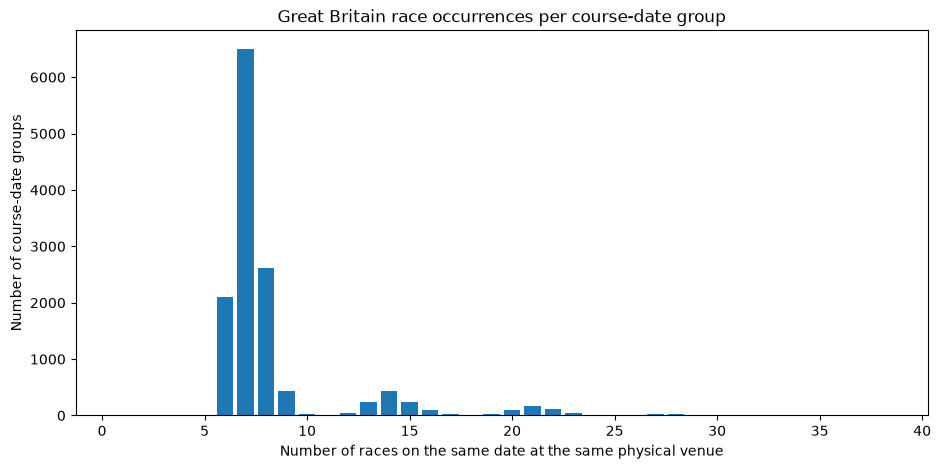

In [9]:
import matplotlib.pyplot as plt

# Plot the full observed distribution before investigating the unusual tail.
# This makes the dominant 6–8 race structure and the much larger course-date
# groups visible without yet deciding what those groups represent.
race_count_distribution = (
    course_date_groups["race_count"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(
    race_count_distribution.index,
    race_count_distribution.values,
)

ax.set_title("Great Britain race occurrences per course-date group")
ax.set_xlabel("Number of races on the same date at the same physical venue")
ax.set_ylabel("Number of course-date groups")

plt.show()

### Visual interpretation

The distribution is highly concentrated rather than evenly spread.

Seven-race course-date groups are by far the most common, with six- and
eight-race groups also accounting for substantial numbers of observations.

There is then a sharp reduction around nine and ten races before a second,
much smaller but clearly visible population appears above roughly twelve races.

The chart therefore reinforces two features already visible in the table:

1. **most British course-date groups resemble conventional single racecards;**
2. **a distinct long upper tail exists and needs explanation before course-date
   grouping can be interpreted as fixture identity.**

The visual does not explain the tail. It only makes its existence and scale
clear.

## Why do some course-date groups contain unusually many races?

### Question

> **What produces the course-date groups containing 12 or more race occurrences?**

### Why this matters

Most Great Britain course-date groups contain six, seven or eight races, which
is broadly compatible with the shape expected of an ordinary day's racecard.

However, substantial numbers of groups contain 12 or more races, with the
largest containing 38.

Before `date + physical venue` can be considered useful evidence about fixture
structure, we need to understand this upper tail.

Possible explanations are not assumed in advance. The large groups could
represent legitimate sporting structure, multiple source course labels sharing
a physical venue, more than one fixture, source/data behaviour, or something
else.

### Evidence / method

We will inspect the largest groups first, retaining the source course label,
date, advertised time and race name so that the underlying races are visible.

In [10]:
# Inspect the largest observed course-date groups at race level.
# Keeping raw course, advertised time and race name visible lets us determine
# what is actually being combined before proposing an explanation.
with connect_read_only(DATABASE) as connection:
    largest_group_races = pd.read_sql_query(
        """
        WITH large_groups AS (
            SELECT
                raw_date,
                physical_venue_name,
                COUNT(*) AS races_on_course_date
            FROM view_reconciled_race_occurrences
            WHERE candidate_jurisdiction = 'Great Britain'
            GROUP BY
                raw_date,
                physical_venue_name
            HAVING COUNT(*) >= 12
        )
        SELECT
            g.races_on_course_date,
            r.raw_date,
            r.physical_venue_name,
            r.raw_course,
            r.candidate_course_label,
            r.raw_off,
            r.race_name_raw
        FROM view_reconciled_race_occurrences AS r
        INNER JOIN large_groups AS g
            ON r.raw_date = g.raw_date
           AND r.physical_venue_name = g.physical_venue_name
        WHERE r.candidate_jurisdiction = 'Great Britain'
        ORDER BY
            g.races_on_course_date DESC,
            r.raw_date,
            r.physical_venue_name,
            r.raw_off
        """,
        connection,
    )

print(
    "Course-date groups with 12+ races:",
    largest_group_races[
        ["raw_date", "physical_venue_name"]
    ].drop_duplicates().shape[0],
)

display(largest_group_races.head(200))

Course-date groups with 12+ races: 0


,races_on_course_date,raw_date,physical_venue_name,raw_course,candidate_course_label,raw_off,race_name_raw


### Result

The attempted inspection returned **zero races**, despite the previous
distribution showing many course-date groups with 12 or more races.

This means the inspection join has failed to recover the groups that produced
the upper tail.

### Interpretation

A likely explanation is that some or all of the unusually large groups have a
missing `physical_venue_name`.

SQLite groups `NULL` values together under `GROUP BY`, but:

`NULL = NULL`

does not evaluate as true in an ordinary join.

That would allow large `(date, NULL)` groups to appear in the distribution while
preventing the subsequent equality join from matching them.

This is currently a hypothesis, not yet an established explanation.

### What this does not establish

We have not yet shown:

- that the large groups all have missing physical venues;
- why those venue values are missing;
- whether the races actually come from multiple courses;
- whether any genuine large non-null venue groups also exist.

### Next question

> **Are the 12+ race course-date groups being created by missing
> `physical_venue_name` values?**

In [11]:
# Inspect the large groups directly rather than joining them back to the race
# table. The NULL flag tests whether missing physical venue values explain the
# upper tail seen in the previous distribution.
with connect_read_only(DATABASE) as connection:
    large_group_summary = pd.read_sql_query(
        """
        SELECT
            raw_date,
            physical_venue_name,
            CASE
                WHEN physical_venue_name IS NULL
                  OR TRIM(physical_venue_name) = ''
                THEN 1
                ELSE 0
            END AS venue_missing,
            COUNT(*) AS race_count,
            COUNT(DISTINCT candidate_course_label) AS distinct_course_labels
        FROM view_reconciled_race_occurrences
        WHERE candidate_jurisdiction = 'Great Britain'
        GROUP BY
            raw_date,
            physical_venue_name
        HAVING COUNT(*) >= 12
        ORDER BY race_count DESC, raw_date
        """,
        connection,
    )

print(f"Groups with 12+ races: {len(large_group_summary):,}")
print()
display(large_group_summary.head(100))

print()
print("Missing-venue breakdown:")
display(
    large_group_summary["venue_missing"]
    .value_counts()
    .rename_axis("venue_missing")
    .to_frame("group_count")
)

Groups with 12+ races: 1,653



,raw_date,physical_venue_name,venue_missing,race_count,distinct_course_labels
0,2023-05-13,None,1,38,5
1,2018-05-12,None,1,36,5
2,2019-05-11,None,1,36,5
3,2021-05-08,None,1,36,5
4,2022-05-07,None,1,36,5
5,2017-05-13,None,1,35,5
6,2015-05-09,None,1,34,5
7,2015-07-18,None,1,34,6
8,2016-05-07,None,1,34,6
9,2016-05-25,None,1,34,5



Missing-venue breakdown:


,group_count
venue_missing,
1,1653


### External verification of the unexpected upper tail

The largest apparent course-date group contained 38 races on 13 May 2023 and
combined five distinct course labels under a missing `physical_venue_name`.

External evidence confirms that multiple separate British racecourses staged
racing that day.

The Jockey Club records separate cards at Warwick, Haydock and Nottingham, while
the BHA separately confirms a Lingfield Park card on the same date.

The apparent 38-race venue was therefore not a real sporting structure. It was
created by grouping multiple races with `physical_venue_name = NULL` together
on the same date.

### Conclusion

`physical_venue_name` cannot be used naively as a fixture-grouping key because
missing values collapse unrelated racecourses into the same group.

The next step is to establish the extent and pattern of missing venue coverage
before choosing another governed representation of course identity.

## Study paused — database investigation required

Exploration of fixture-like course-date groupings exposed a material database
issue.

Grouping Great Britain races by `raw_date + physical_venue_name` initially
produced apparent groups containing as many as 38 races.

Investigation established that every one of the **1,653 groups containing 12 or
more races** had `physical_venue_name = NULL`. Multiple unrelated course labels
were therefore being collapsed together merely because they shared the same
date and a missing venue value.

An external check of 13 May 2023 confirmed that the apparent 38-race group
represented racing at multiple separate racecourses rather than a genuine
single-venue racing structure.

### Why the study is paused

The study now requires a reliable governed representation of British
course/venue identity before fixture structure can be investigated safely.

Under the Study Research Playbook, this is database/governance work rather than
a study-specific workaround.

The study is therefore paused while the database investigation establishes:

1. the extent and pattern of missing `physical_venue_name` values;
2. why those values are missing;
3. whether existing course/venue mappings are incomplete or behaving as
   designed;
4. whether a database correction or reusable enhancement is required;
5. the governed field or structure studies should use for course/venue identity.

The exploratory result and failed grouping are retained because they document
how the issue was discovered.

### Resume condition

Resume this study only after the database investigation has established the
appropriate governed representation of British course/venue identity and any
required database work has been completed and documented.

## How many races are normally run at a British meeting?

The previous calculation grouped races by date and `physical_venue_name`. That was the wrong field for this question because `physical_venue_name` is optional location enrichment and is blank for a substantial number of otherwise governed British course identities.

For the present analysis, a meeting is therefore provisionally defined as:

> **one governed course/configuration identity on one race date**

The calculation below groups British races by `raw_date + candidate_course_label`.

This does not attempt to decide whether labels such as `Kempton` and `Kempton (AW)` represent the same physical racecourse. That is a separate course-identity question and is outside this study.

In [14]:
from pathlib import Path

import pandas as pd

from inside_rails.source_sqlite import connect_read_only


# Resolve the repository root without assuming the notebook's working directory.
project_root = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "data" / "processed" / "database" / "releases" / "inside_rails_v3.sqlite3").exists()
)

database_path = (
    project_root
    / "data"
    / "processed"
    / "database"
    / "releases"
    / "inside_rails_v3.sqlite3"
)

# A meeting is provisionally one governed course/configuration identity on one race date.
# physical_venue_name is deliberately not used because it is optional location enrichment.
with connect_read_only(database_path) as conn:
    meeting_sizes = pd.read_sql_query(
        """
        SELECT
            raw_date,
            candidate_course_label,
            COUNT(*) AS races_in_meeting
        FROM view_reconciled_race_occurrences
        WHERE candidate_jurisdiction = 'Great Britain'
        GROUP BY
            raw_date,
            candidate_course_label
        """,
        conn,
    )

# Summarise at meeting grain after the database connection has been safely closed.
meeting_size_distribution = (
    meeting_sizes["races_in_meeting"]
    .value_counts()
    .sort_index()
    .rename_axis("races_in_meeting")
    .reset_index(name="meetings")
)

print(f"British races represented: {meeting_sizes['races_in_meeting'].sum():,}")
print(f"Course-date meetings: {len(meeting_sizes):,}")
print(f"Minimum races in a meeting: {meeting_sizes['races_in_meeting'].min()}")
print(f"Median races in a meeting: {meeting_sizes['races_in_meeting'].median():.0f}")
print(f"Maximum races in a meeting: {meeting_sizes['races_in_meeting'].max()}")

display(meeting_size_distribution)

display(
    meeting_sizes.sort_values(
        ["races_in_meeting", "raw_date", "candidate_course_label"],
        ascending=[False, True, True],
    ).head(20)
)

British races represented: 111,634
Course-date meetings: 15,865
Minimum races in a meeting: 1
Median races in a meeting: 7
Maximum races in a meeting: 10


,races_in_meeting,meetings
0,1,53
1,2,28
2,3,75
3,4,70
4,5,41
5,6,2873
6,7,8800
7,8,3368
8,9,537
9,10,20


,raw_date,candidate_course_label,races_in_meeting
7511,2020-06-01,Newcastle (AW),10
7513,2020-06-02,Newcastle (AW),10
7515,2020-06-03,Yarmouth,10
7516,2020-06-04,Newcastle (AW),10
7517,2020-06-06,Newcastle (AW),10
7518,2020-06-08,Chelmsford (AW),10
7528,2020-06-16,Chelmsford (AW),10
7534,2020-06-26,Doncaster,10
7538,2020-06-30,Doncaster,10
7550,2020-07-09,York,10


### Interpretation

Using the governed course/configuration identity rather than the optional physical-venue enrichment produces a plausible meeting-size distribution.

Across 111,634 British races, the data contains 15,865 course-date meetings. Seven races is the most common meeting size and also the median. Most meetings contain between six and eight races, while very short and very long cards are uncommon.

The maximum observed size is 10 races. The earlier apparent meetings containing dozens of races were therefore caused by grouping on a nullable physical-venue enrichment field rather than by genuine British race-meeting structure or a Database v3 defect.

For this analysis, a **course-date meeting** means one `candidate_course_label` on one `raw_date`. This is an analytical definition appropriate to the present question; it is not intended to resolve the separate question of physical racecourse or venue identity.

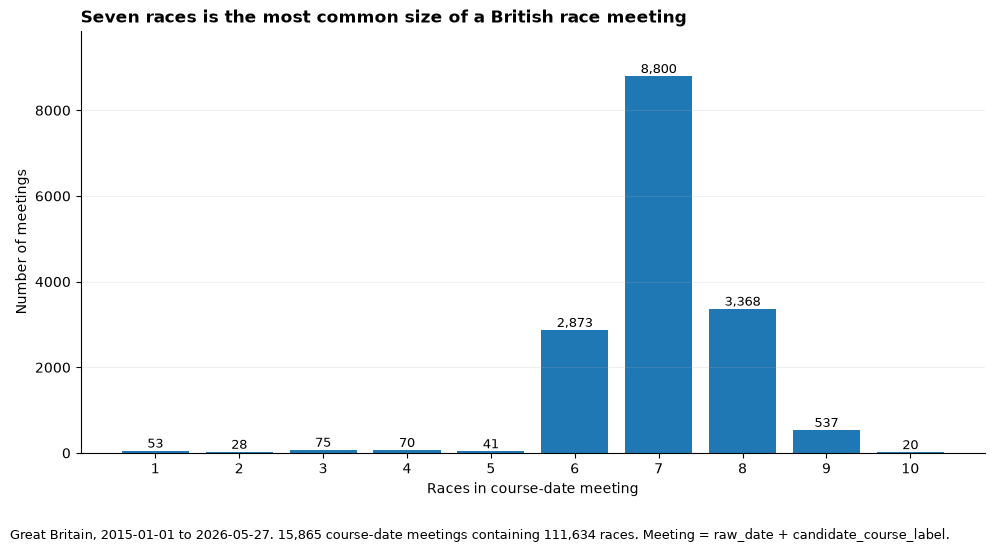

In [17]:
import matplotlib.pyplot as plt


# Plot the complete meeting-size distribution so the dominant six-to-eight-race
# structure and the uncommon tails remain visible rather than being bucketed.
fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.bar(
    meeting_size_distribution["races_in_meeting"],
    meeting_size_distribution["meetings"],
)

ax.set_title(
    "Seven races is the most common size of a British race meeting",
    loc="left",
    fontweight="bold",
)
ax.set_xlabel("Races in course-date meeting")
ax.set_ylabel("Number of meetings")
ax.set_xticks(meeting_size_distribution["races_in_meeting"])
ax.set_ylim(0, meeting_size_distribution["meetings"].max() * 1.12)

# Keep the actual meeting counts visible so the chart remains interpretable
# without requiring the reader to refer back to the preceding table.
for bar, meetings in zip(bars, meeting_size_distribution["meetings"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{meetings:,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2)

fig.text(
    0.01,
    0.01,
    (
        "Great Britain, 2015-01-01 to 2026-05-27. "
        "15,865 course-date meetings containing 111,634 races. "
        "Meeting = raw_date + candidate_course_label."
    ),
    ha="left",
    fontsize=9,
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

### What the distribution shows

British race meetings are strongly concentrated around seven races.

Of the 15,865 course-date meetings observed between 2015 and May 2026, 8,800 — 55.5% — contained exactly seven races. A further 2,873 contained six races and 3,368 contained eight.

Together, six-, seven- and eight-race meetings account for 94.8% of the observed population.

Meeting sizes outside that range are comparatively unusual. Only 1.7% contain five races or fewer, while 3.5% contain nine or ten races.

The evidence therefore establishes a clear descriptive feature of the British racing programme: **a course-date meeting is usually built around a six- to eight-race card, with seven races by far the most common single size.**

This does not yet establish whether that structure was stable throughout the period, whether particular years or circumstances produced different meeting sizes, or why meetings are commonly organised this way.

## Has the size of a British race meeting changed over time?

The overall distribution shows that seven races is by far the most common meeting size, but that result combines more than eleven years of racing.

The largest observed meetings also appeared disproportionately in 2020, so the next question is whether the structure of a British meeting has remained broadly stable through time or whether particular years differ materially.

For each calendar year, the analysis below reports:

- the number of course-date meetings;
- the median number of races per meeting;
- the percentage of meetings containing exactly 6, 7 or 8 races;
- the percentage containing 9 or more races.

The 2026 figures are partial because Database v3 ends on 27 May 2026.

In [19]:
# Add calendar year from the governed race date already used to define meetings.
meeting_sizes_by_year = meeting_sizes.copy()
meeting_sizes_by_year["year"] = (
    meeting_sizes_by_year["raw_date"].str.slice(0, 4).astype(int)
)

# Summarise meeting structure within each calendar year.
annual_meeting_structure = (
    meeting_sizes_by_year
    .groupby("year")
    .agg(
        meetings=("races_in_meeting", "size"),
        median_races=("races_in_meeting", "median"),
        six_races=("races_in_meeting", lambda x: (x == 6).sum()),
        seven_races=("races_in_meeting", lambda x: (x == 7).sum()),
        eight_races=("races_in_meeting", lambda x: (x == 8).sum()),
        nine_plus_races=("races_in_meeting", lambda x: (x >= 9).sum()),
    )
    .reset_index()
)

# Convert counts to percentages while retaining the annual meeting denominator.
for count_column, pct_column in [
    ("six_races", "pct_6_races"),
    ("seven_races", "pct_7_races"),
    ("eight_races", "pct_8_races"),
    ("nine_plus_races", "pct_9_plus_races"),
]:
    annual_meeting_structure[pct_column] = (
        100
        * annual_meeting_structure[count_column]
        / annual_meeting_structure["meetings"]
    )

display(
    annual_meeting_structure[
        [
            "year",
            "meetings",
            "median_races",
            "pct_6_races",
            "pct_7_races",
            "pct_8_races",
            "pct_9_plus_races",
        ]
    ].round(
        {
            "median_races": 1,
            "pct_6_races": 1,
            "pct_7_races": 1,
            "pct_8_races": 1,
            "pct_9_plus_races": 1,
        }
    )
)

,year,meetings,median_races,pct_6_races,pct_7_races,pct_8_races,pct_9_plus_races
0,2015,1459,7.0,21.0,57.9,18.6,0.0
1,2016,1447,7.0,19.9,56.7,21.4,0.0
2,2017,1474,7.0,19.0,57.4,22.1,0.1
3,2018,1486,7.0,15.7,58.6,23.8,0.0
4,2019,1454,7.0,18.6,60.8,18.6,0.2
5,2020,827,8.0,8.9,35.9,32.5,20.8
6,2021,1444,7.0,10.5,57.8,28.4,2.0
7,2022,1442,7.0,13.9,63.0,19.9,1.8
8,2023,1436,7.0,19.7,57.6,17.3,3.6
9,2024,1424,7.0,24.1,47.1,18.2,8.3


### Interpretation

Meeting size has not been completely stable through time.

From 2015 to 2019 the structure was remarkably consistent: the annual median remained seven races and around three-fifths of meetings contained exactly seven races.

The clearest break occurs in 2020. The median rises to eight races, seven-race meetings become much less common, and more than one-fifth of meetings contain nine or more races. External BHA evidence confirms that 2020 operated under an exceptional reconstructed race programme following the COVID-19 suspension, so this should not be interpreted as a normal long-term change.

The distribution then moves back towards seven-race meetings in 2021 and 2022.

A second change becomes visible from 2023. Six-race meetings become increasingly common while nine-or-more-race meetings also increase, reducing the dominance of the seven-race card. This is consistent with BHA programme changes that deliberately redistributed race volume between periods and surfaces rather than maintaining a single fixed number of races per fixture.

The 2026 figures cover only the period to 27 May and should not be treated as a complete annual comparison.

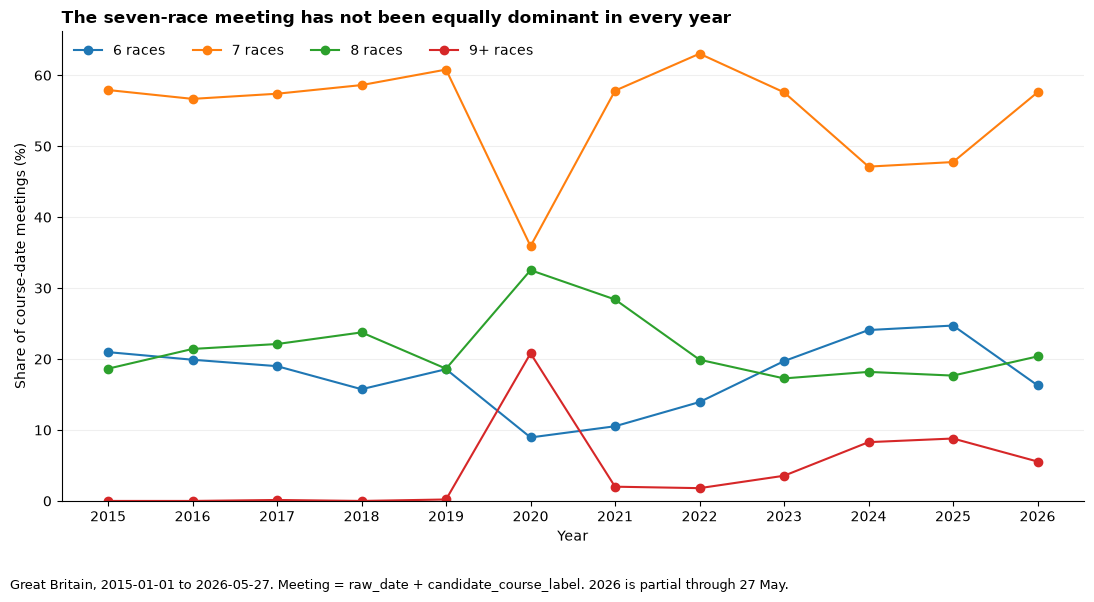

In [20]:
import matplotlib.pyplot as plt


# Plot annual shares rather than raw meeting counts so years with different
# numbers of fixtures, especially 2020 and partial 2026, remain comparable.
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    annual_meeting_structure["year"],
    annual_meeting_structure["pct_6_races"],
    marker="o",
    label="6 races",
)
ax.plot(
    annual_meeting_structure["year"],
    annual_meeting_structure["pct_7_races"],
    marker="o",
    label="7 races",
)
ax.plot(
    annual_meeting_structure["year"],
    annual_meeting_structure["pct_8_races"],
    marker="o",
    label="8 races",
)
ax.plot(
    annual_meeting_structure["year"],
    annual_meeting_structure["pct_9_plus_races"],
    marker="o",
    label="9+ races",
)

ax.set_title(
    "The seven-race meeting has not been equally dominant in every year",
    loc="left",
    fontweight="bold",
)
ax.set_xlabel("Year")
ax.set_ylabel("Share of course-date meetings (%)")
ax.set_xticks(annual_meeting_structure["year"])
ax.set_ylim(bottom=0)

ax.legend(frameon=False, ncol=4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2)

fig.text(
    0.01,
    0.01,
    (
        "Great Britain, 2015-01-01 to 2026-05-27. "
        "Meeting = raw_date + candidate_course_label. "
        "2026 is partial through 27 May."
    ),
    ha="left",
    fontsize=9,
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

### What changed through time?

The typical British meeting structure has not been completely stable.

From 2015 to 2019, seven-race meetings consistently dominated. The exceptional 2020 season produced a very different distribution, with far more eight-race and nine-or-more-race cards.

The distribution then moved back towards the earlier pattern, but 2024 and 2025 show another change: seven-race meetings became less dominant while both six-race and longer cards became more common.

The aggregate result therefore hides meaningful variation through time. Seven races remains the most common single meeting size overall, but it should not be treated as a fixed structural rule.

The 2026 data is incomplete through 27 May and is not directly comparable with complete calendar years.

## Does a British meeting contain one race type?

Before comparing meeting sizes between different forms of racing, we need to establish whether a course-date meeting can be assigned a single race type.

The next check counts the number of distinct governed source race-type labels appearing within each course-date meeting.

In [21]:
# Check whether individual course-date meetings contain one or multiple
# race-type labels before assigning a meeting-level racing category.
with connect_read_only(database_path) as conn:
    meeting_race_type_counts = pd.read_sql_query(
        """
        SELECT
            raw_date,
            candidate_course_label,
            COUNT(DISTINCT race_type_raw) AS distinct_race_types
        FROM view_reconciled_race_occurrences
        WHERE candidate_jurisdiction = 'Great Britain'
        GROUP BY
            raw_date,
            candidate_course_label
        """,
        conn,
    )

display(
    meeting_race_type_counts["distinct_race_types"]
    .value_counts()
    .sort_index()
    .rename_axis("distinct_race_types")
    .reset_index(name="meetings")
)

,distinct_race_types,meetings
0,1,9916
1,2,3141
2,3,2807
3,4,1


### Interpretation

A British course-date meeting cannot safely be assigned a single `race_type_raw` value.

Although 62.5% of meetings contain only one distinct race-type label, 37.5% contain two or more. Multi-type meetings are therefore a substantial part of the observed population rather than an exceptional case.

This does not yet establish whether those meetings mix fundamentally different forms of racing or whether the multiple labels represent related race types within a broader racing code.

Before creating any meeting-level Flat/Jump classification, we therefore need to inspect the actual combinations of race-type labels occurring within meetings.

In [22]:
# Preserve the actual set of source race-type labels within each meeting.
# This establishes what the multi-type meetings contain before we attempt
# any broader meeting-level racing classification.
with connect_read_only(database_path) as conn:
    meeting_race_type_combinations = pd.read_sql_query(
        """
        WITH meeting_types AS (
            SELECT DISTINCT
                raw_date,
                candidate_course_label,
                race_type_raw
            FROM view_reconciled_race_occurrences
            WHERE candidate_jurisdiction = 'Great Britain'
        ),
        ordered_types AS (
            SELECT
                raw_date,
                candidate_course_label,
                race_type_raw
            FROM meeting_types
            ORDER BY
                raw_date,
                candidate_course_label,
                race_type_raw
        ),
        combinations AS (
            SELECT
                raw_date,
                candidate_course_label,
                GROUP_CONCAT(race_type_raw, ' + ') AS race_type_combination
            FROM ordered_types
            GROUP BY
                raw_date,
                candidate_course_label
        )
        SELECT
            race_type_combination,
            COUNT(*) AS meetings
        FROM combinations
        GROUP BY race_type_combination
        ORDER BY
            meetings DESC,
            race_type_combination
        """,
        conn,
    )

display(meeting_race_type_combinations)

,race_type_combination,meetings
0,Flat,9784
1,Chase + Hurdle,3104
2,Chase + Hurdle + NH Flat,2790
3,NH Flat,60
4,Chase,53
5,Hurdle + NH Flat,27
6,Hurdle,19
7,Chase + Flat + Hurdle,12
8,Chase + Flat,6
9,Flat + Hurdle + NH Flat,5


### Interpretation

The multiple race-type labels within British meetings mostly reflect the structure of National Hunt racing rather than meetings mixing fundamentally different racing codes.

Of 15,865 course-date meetings:

- 9,784 (61.7%) contain `Flat` races only;
- 6,056 (38.2%) contain only combinations of `Chase`, `Hurdle` and `NH Flat`;
- just 25 (0.16%) contain both `Flat` and at least one National Hunt race-type label.

This suggests that a broader meeting-level distinction between Flat racing and National Hunt racing may be analytically defensible for almost the entire population.

The 25 apparent mixed Flat/National Hunt meetings are unexpected, however. They must be inspected and, where material, externally verified before being treated as genuine mixed-code race meetings.

In [24]:
# Inspect the small residue of course-date meetings containing both `Flat`
# and at least one National Hunt-family race type.
#
# No source `raw_off` value is used here: race time is not required to answer
# this question, and raw source time should not be substituted for the governed
# time fields merely for display or ordering.
with connect_read_only(database_path) as conn:
    mixed_code_meetings = pd.read_sql_query(
        """
        WITH meeting_flags AS (
            SELECT
                raw_date,
                candidate_course_label,
                MAX(CASE WHEN race_type_raw = 'Flat' THEN 1 ELSE 0 END) AS has_flat,
                MAX(
                    CASE
                        WHEN race_type_raw IN ('Chase', 'Hurdle', 'NH Flat')
                        THEN 1 ELSE 0
                    END
                ) AS has_nh
            FROM view_reconciled_race_occurrences
            WHERE candidate_jurisdiction = 'Great Britain'
            GROUP BY
                raw_date,
                candidate_course_label
        )
        SELECT
            r.raw_date,
            r.candidate_course_label,
            r.race_type_raw,
            r.race_name_raw
        FROM view_reconciled_race_occurrences AS r
        JOIN meeting_flags AS m
          ON m.raw_date = r.raw_date
         AND m.candidate_course_label = r.candidate_course_label
        WHERE r.candidate_jurisdiction = 'Great Britain'
          AND m.has_flat = 1
          AND m.has_nh = 1
        ORDER BY
            r.raw_date,
            r.candidate_course_label,
            r.race_type_raw,
            r.race_name_raw
        """,
        conn,
    )

display(mixed_code_meetings)

,raw_date,candidate_course_label,race_type_raw,race_name_raw
0,2015-02-13,Sandown,Chase,Alanbrooke Handicap Chase
1,2015-02-13,Sandown,Chase,Ubique Handicap Chase
2,2015-02-13,Sandown,Flat,Royal Artillery Gold Cup (Chase For Military Amateur Riders)(Supported By Morgan Advanced Materials)
3,2015-02-13,Sandown,Hurdle,David Lindon & Co Novices Hurdle
4,2015-02-13,Sandown,Hurdle,EstatesDirect.com The 0% Commission Agent Conditional Jockeys Handicap Hurdle
5,2015-02-13,Sandown,Hurdle,Oxshott Novices Handicap Hurdle
6,2015-02-13,Sandown,Hurdle,Weatherbys GSB Jane Seymour Mares Novices Hurdle ()
7,2015-03-06,Sandown,Chase,Ssafa Forces Family Handicap Chase
8,2015-03-06,Sandown,Flat,Grand Military Gold Cup (Chase For Military Amateur Riders) (Sponsored By The Military Mutual)
9,2015-03-06,Sandown,Hurdle,Anne Boleyn Mares Novices Hurdle
